In [1]:
import pandas as pd
import joblib

df_raw = pd.read_csv('../data/processed/train_balanced.csv')
print(df_raw.shape)
print(df_raw.columns.tolist())
print(df_raw.iloc[:, -1].value_counts())

# Separar variables predictoras y target
X = df_raw.drop("y", axis=1)
y = df_raw["y"]

# Cargar modelos entrenados
models = {
    "lr": joblib.load("../models/baseline_lr.pkl"),
    "dt": joblib.load("../models/baseline_dt.pkl"),
    "rf": joblib.load("../models/baseline_rf.pkl"),
    "svm": joblib.load("../models/baseline_svm.pkl"),
    "knn": joblib.load("../models/baseline_knn.pkl")
}

print("X:", X.shape)
print("y:", y.shape)
print("Modelos cargados:", list(models.keys()))

(58456, 45)
['age', 'education', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success', 'contacted_before', 'campaign_intensity', 'has_loan_or_housing', 'y']
y
0    29228
1    29228
Name: count, dtype: int64
X: (58456, 44)
y: (58456,)
Modelos cargados: ['lr', 'dt', 'rf', 'svm', 'knn']


In [2]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Muestra para CV (SVM no escala bien)
X_sample = X.sample(n=10000, random_state=42)
y_sample = y[X_sample.index]

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():

    if name == "svm":
        print("Saltando SVM por alto costo computacional en validación cruzada.")
        results[name] = {
            "accuracy": "No ejecutado",
            "precision": "No ejecutado",
            "recall": "No ejecutado",
            "f1": "No ejecutado",
            "roc_auc": "No ejecutado"
        }
        continue

    print(f"Evaluando {name}...")

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    results[name] = {
        m: f"{scores[f'test_{m}'].mean():.4f} ± {scores[f'test_{m}'].std():.4f}"
        for m in scoring
    }

df_results = pd.DataFrame(results).T
display(df_results)

Evaluando lr...
Evaluando dt...
Evaluando rf...
Saltando SVM por alto costo computacional en validación cruzada.
Evaluando knn...


,accuracy,precision,recall,f1,roc_auc
lr,0.7957 ± 0.0031,0.8150 ± 0.0030,0.7652 ± 0.0057,0.7893 ± 0.0036,0.8819 ± 0.0028
dt,0.8880 ± 0.0031,0.8820 ± 0.0026,0.8959 ± 0.0037,0.8889 ± 0.0031,0.8894 ± 0.0029
rf,0.9290 ± 0.0010,0.9306 ± 0.0031,0.9271 ± 0.0021,0.9288 ± 0.0009,0.9771 ± 0.0011
svm,No ejecutado,No ejecutado,No ejecutado,No ejecutado,No ejecutado
knn,0.8504 ± 0.0036,0.8173 ± 0.0051,0.9025 ± 0.0025,0.8578 ± 0.0031,0.9170 ± 0.0021



lr
              precision    recall  f1-score   support

          No       0.94      0.84      0.88      7307
         Yes       0.30      0.54      0.38       927

    accuracy                           0.80      8234
   macro avg       0.62      0.69      0.63      8234
weighted avg       0.86      0.80      0.83      8234


dt
              precision    recall  f1-score   support

          No       0.92      0.89      0.90      7307
         Yes       0.29      0.36      0.33       927

    accuracy                           0.83      8234
   macro avg       0.61      0.63      0.61      8234
weighted avg       0.85      0.83      0.84      8234


rf
              precision    recall  f1-score   support

          No       0.92      0.94      0.93      7307
         Yes       0.44      0.39      0.42       927

    accuracy                           0.88      8234
   macro avg       0.68      0.66      0.67      8234
weighted avg       0.87      0.88      0.87      8234


svm
  

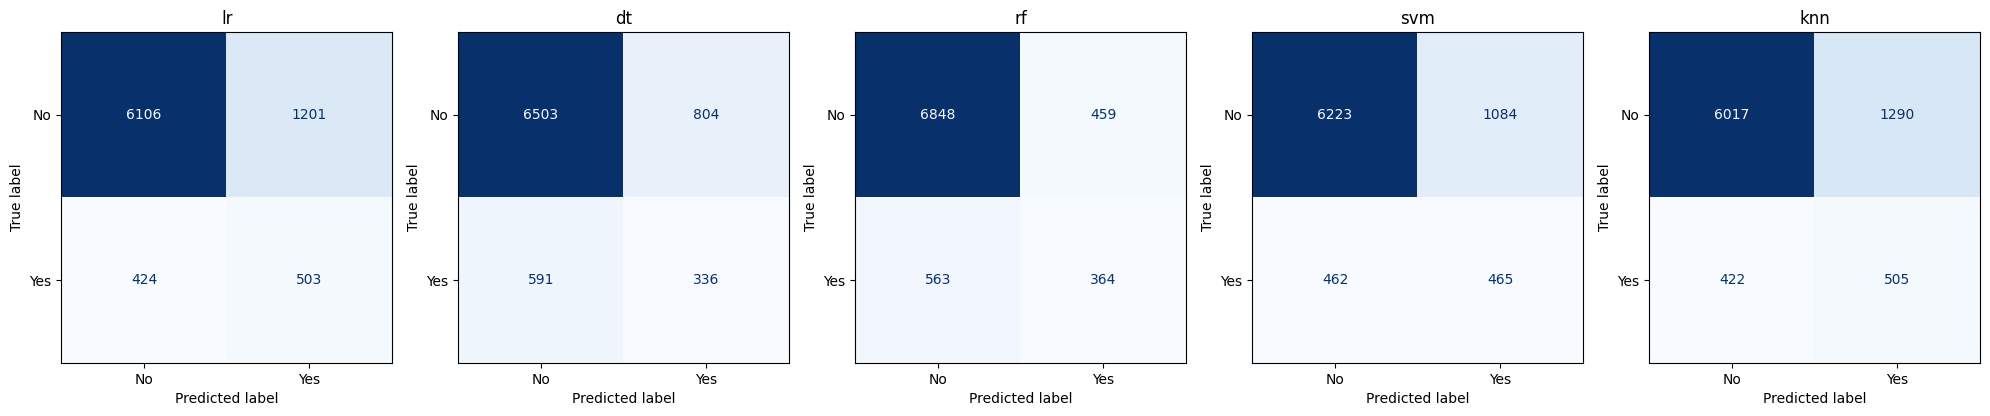

In [3]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df_test = pd.read_csv('../data/processed/test_original.csv')
X_test = df_test.drop(columns='y')
y_test = df_test['y']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}\n{name}")
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['No', 'Yes'],
        colorbar=False, ax=ax, cmap='Blues'
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [4]:
### Nota sobre SVM

## El modelo SVM fue entrenado correctamente en `09_baseline_models.ipynb`; sin embargo, durante la validación cruzada de 5 folds presentó un costo computacional elevado en el equipo local. Por ello, se documenta como modelo entrenado, pero no se reporta cross-validation completa. Esta limitación se considera para Sprint 4, donde se priorizará optimizar modelos con mejor relación desempeño-tiempo.

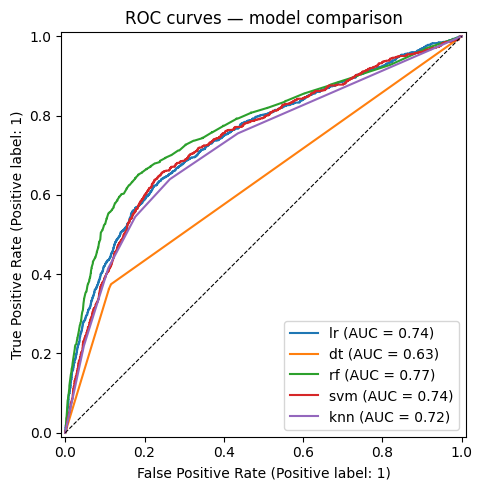

In [5]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_title('ROC curves — model comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

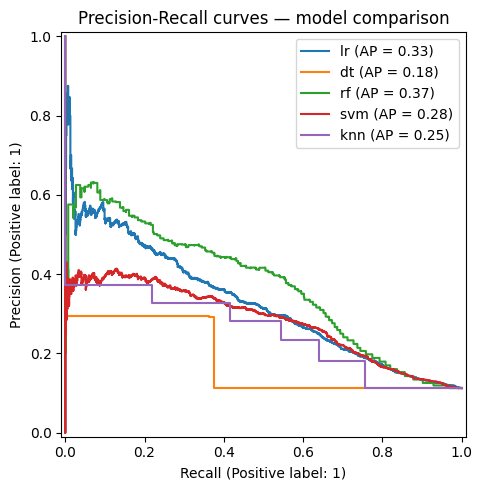

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title('Precision-Recall curves — model comparison')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [7]:
df_results.to_csv("../models/evaluation_cv_results.csv", index=True)
df_results

,accuracy,precision,recall,f1,roc_auc
lr,0.7957 ± 0.0031,0.8150 ± 0.0030,0.7652 ± 0.0057,0.7893 ± 0.0036,0.8819 ± 0.0028
dt,0.8880 ± 0.0031,0.8820 ± 0.0026,0.8959 ± 0.0037,0.8889 ± 0.0031,0.8894 ± 0.0029
rf,0.9290 ± 0.0010,0.9306 ± 0.0031,0.9271 ± 0.0021,0.9288 ± 0.0009,0.9771 ± 0.0011
svm,No ejecutado,No ejecutado,No ejecutado,No ejecutado,No ejecutado
knn,0.8504 ± 0.0036,0.8173 ± 0.0051,0.9025 ± 0.0025,0.8578 ± 0.0031,0.9170 ± 0.0021
